# Wykrywanie oszustw związanych z kartami płatniczymi

---
Projekt dotyczy analizy zbioru danych dotyczących transakcji kartą kredytową. Analiza polegać będzie na przewidywaniu, czy dana transakcja jest oszustwem, czy nie. Dane pochodzą z platformy Kaggle i znajdują się pod tym linkiem: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/code. Poniżej zamieszczono opis danych ze strony (przetłumaczony na język polski).

---
Zbiór danych zawiera transakcje dokonane kartami kredytowymi we wrześniu 2013 roku przez europejskich posiadaczy kart.

Zestaw ten przedstawia transakcje, które miały miejsce w ciągu dwóch dni, gdzie odnotowano 492 oszustwa na 284 807 transakcji. Zbiór jest silnie niezbalansowany – klasa pozytywna stanowi zaledwie 0,172% wszystkich operacji.

Dane zawierają wyłącznie numeryczne zmienne wejściowe, które są wynikiem transformacji PCA. Niestety, ze względu na kwestie poufności, oryginalne cechy oraz dodatkowe informacje kontekstowe nie zostały udostępnione. Cechy od $V1$ do $V28$ to główne składowe uzyskane za pomocą PCA. Jedynymi cechami, które nie zostały poddane tej transformacji, są $Time$ oraz $Amount$.

- Cecha $Time$ zawiera liczbę sekund, które upłynęły między daną transakcją a pierwszą transakcją w zbiorze danych. Cecha ta została usunięta.

- Cecha $Amount$ to kwota transakcji; cecha ta może zostać wykorzystana na przykład w uczeniu wrażliwym na koszty.

- Cecha $Class$ jest zmienną objaśnianą i przyjmuje wartość 1 w przypadku oszustwa oraz 0 w przeciwnym razie.

---
Analiza projektu polegać będzie na wstępnej eksploracji danych, który pozwoli na lepsze zrozumienie zbioru. Następnie na danych zostaną wykonane poszczególne metody uczenia maszynowego. Na końcu wszystkie modele zostaną ze sobą porównane.


Metody użyte w tym projekcie to:
- **Metoda K-Nearest Neigbors**
- **Random Forest**
- **Naiwny klasyfikator Bayesowski**
- **Regresja logistyczna**
- **Model SVM**

## Importowanie pliku i bibliotek

In [2]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=6b85b0124469ac21dfe80879c782b9207687a23f650c8d9b7c3df11c87174f52
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lime
import lime.lime_tabular

In [4]:
credit = pd.read_csv('creditcard.csv')
credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Wstępna eksploracja danych

Zbiór danych zawiera **284807** niepustych rekordów.

In [5]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
credit.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
print(f"Zbiór danych ma {credit.shape[0]} wierszy i {credit.shape[1]} kolumn")

Zbiór danych ma 284807 wierszy i 31 kolumn


In [7]:
print(f"Liczba wartości nan w zbiorze: {credit.isnull().sum().sum()}")

Liczba wartości nan w zbiorze: 0


### Rozkład gęstości

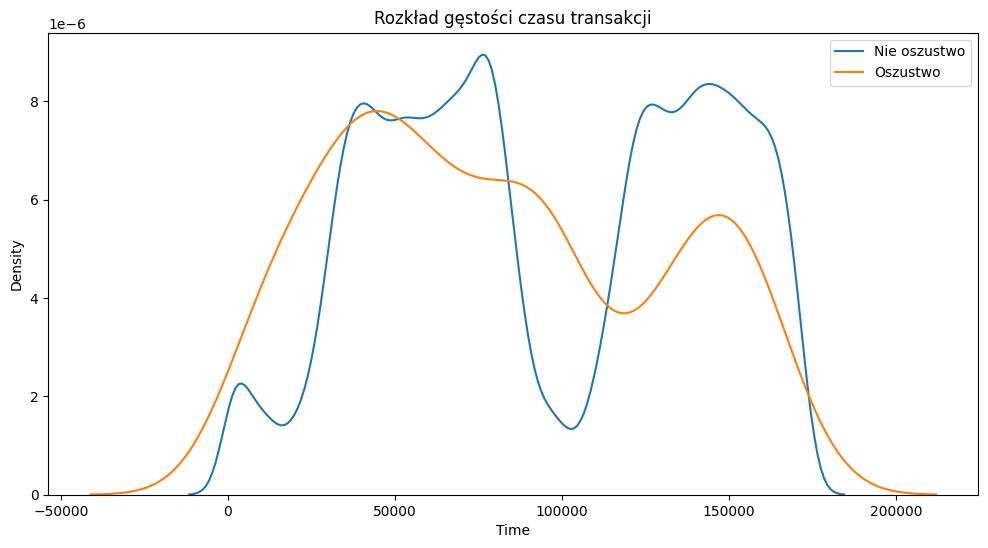

In [8]:
class_0 = credit[credit['Class']==0]['Time']
class_1 = credit[credit['Class']==1]['Time']
class_0 = pd.DataFrame(class_0)
class_1 = pd.DataFrame(class_1)

plt.figure(figsize=(12, 6))

sns.kdeplot(data=class_0, x="Time", label='Nie oszustwo')
sns.kdeplot(data=class_1, x="Time", label='Oszustwo')

plt.title("Rozkład gęstości czasu transakcji")
plt.legend()
plt.show()

Wykres gęstości prezentuje rozkład transakcji w czasie dwóch dni, gdzie wyraźne doliny w niebieskiej linii (transakcje legalne) odpowiadają godzinom nocnym i naturalnemu spadkowi aktywności klientów. Linia pomarańczowa (oszustwa) jest znacznie bardziej płaska, co sugeruje, że przestępcy działają w sposób ciągły, często wykorzystując właśnie okresy mniejszego ruchu do przeprowadzania ataków. Mimo tych różnic, oba rozkłady w znacznym stopniu nakładają się na siebie, co potwierdza małą wartość predykcyjną samej zmiennej czasowej i uzasadnia jej usunięcie przed procesem trenowania modeli.

In [9]:
non_frauds_count = class_0.count().values[0]
frauds_count = class_1.count().values[0]

print(f"Zbiór danych zawiera {frauds_count} przypadków oszustwa oraz {non_frauds_count} przypadków, które nie były oszustwem. Oszustwa stanowią {round(frauds_count / non_frauds_count * 100, 2)}% wszystkich transakcji.")

Zbiór danych zawiera 492 przypadków oszustwa oraz 284315 przypadków, które nie były oszustwem. Oszustwa stanowią 0.17% wszystkich transakcji.


### Korelacja danych

In [10]:
credit_corr = credit.corr()


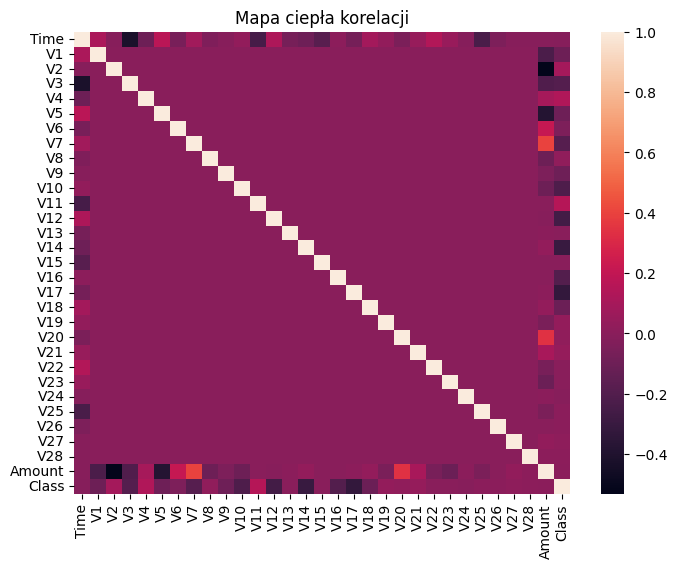

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(credit_corr)
plt.title("Mapa ciepła korelacji")

plt.show()

Większość danych **nie ma** za sobą żadnej korelacji.

### Zależność pomiędzy oszustwem, a czasem

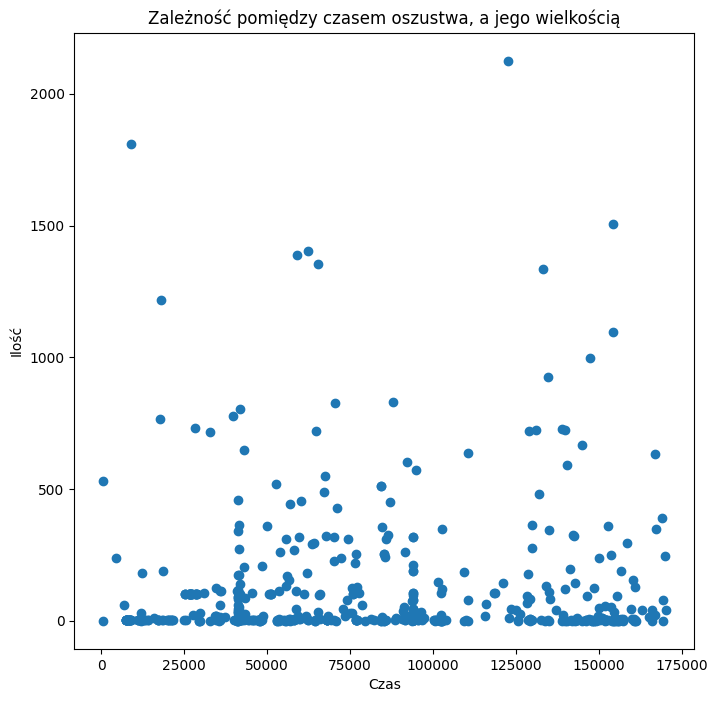

In [12]:
credit_fr = credit[credit['Class']==1]
credit_fr

plt.figure(figsize=(8, 8))
plt.scatter(credit_fr['Time'], credit_fr['Amount'])
plt.title("Zależność pomiędzy czasem oszustwa, a jego wielkością")
plt.xlabel("Czas")
plt.ylabel("Ilość")

plt.show()

Z powyższego wykresu wynika, że czas nie ma żadnego wpływa na wielkość oszustwa. Dodatkowo, większość oszustw została wykonana na małych kwotach.

# Przygotowanie modelu

Naszą zmienną przewidywaną będzie kolumna "Class".

In [13]:
credit = credit.drop(['Time'], axis=1)
X = credit.iloc[:, :-1].values
y = credit.iloc[:, -1].values

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Wymiary testu treningowego: {X_train.shape}")
print(f"Wymiary testu testowego: {y_train.shape}")

Wymiary testu treningowego: (199364, 29)
Wymiary testu testowego: (199364,)


In [15]:
klasy_train, n_train = np.unique(y_train, return_counts=True)
klasy_test, n_test = np.unique(y_test, return_counts=True)

print(f'Rozkład w zbiorze treningowym:')
for klasa, liczba in zip(klasy_train, n_train):
    print(f'  {klasa}: {liczba} ({liczba/len(y_train)*100:.1f}%)')

print(f'\nRozkład w zbiorze testowym:')
for klasa, liczba in zip(klasy_test, n_test):
    print(f'  {klasa}: {liczba} ({liczba/len(y_test)*100:.1f}%)')

Rozkład w zbiorze treningowym:
  0: 199008 (99.8%)
  1: 356 (0.2%)

Rozkład w zbiorze testowym:
  0: 85307 (99.8%)
  1: 136 (0.2%)


## Predykcje

### K-Nearest Neighbours

Pierwszym modelem klasyfikacji będzie model K-Nearest Neighbours. Model K-Nearest Neighbours to algorytm, który klasyfikuje nowy obiekt na podstawie większościowego głosu jego k najbliższych sąsiadów z danych treningowych.

In [ ]:
k_values = [1, 3, 5, 10, 20]
accuracies = []

for k in k_values:
  model_knn = KNeighborsClassifier(n_neighbors=k)
  model_knn.fit(X_train, y_train)
  y_pred_knn = model_knn.predict(X_test)
  acc = accuracy_score(y_test, y_pred_knn)
  accuracies.append(acc)

In [ ]:
for acc, k in zip(accuracies, k_values):
  print(f"Liczba k wynosząca {k} ma dokładność: {round(acc, 5)}")

Liczba k wynosząca 1 ma dokładność: 0.99933
Liczba k wynosząca 3 ma dokładność: 0.9994
Liczba k wynosząca 5 ma dokładność: 0.99929
Liczba k wynosząca 10 ma dokładność: 0.99913
Liczba k wynosząca 20 ma dokładność: 0.99906


In [ ]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)

=== k-Nearest Neighbors (k=3) ===
Accuracy: 0.9993

Macierz pomyłek:
[[85298     9]
 [   52    84]]


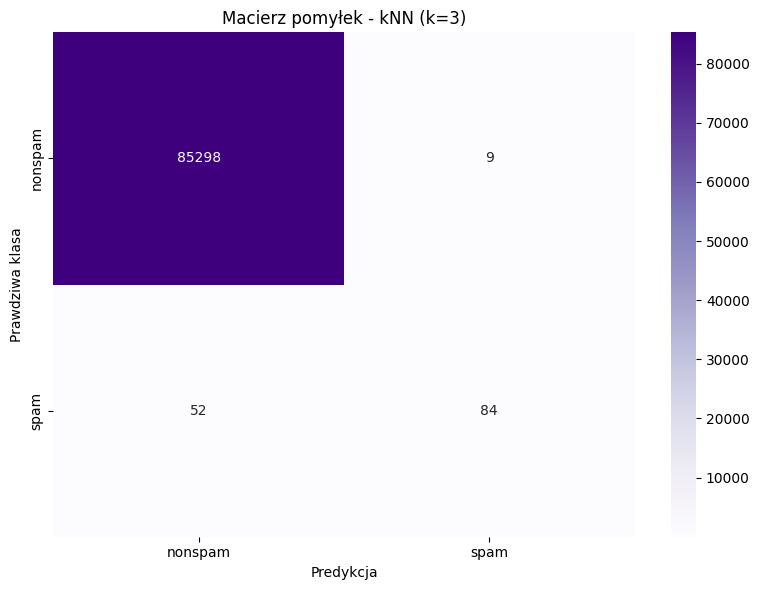


Raport klasyfikacji:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.90      0.62      0.73       136

    accuracy                           1.00     85443
   macro avg       0.95      0.81      0.87     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
print("=== k-Nearest Neighbors (k=3) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

print("\nMacierz pomyłek:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['nonfraud', 'fraud'],
            yticklabels=['nonfraud', 'fraud'])
plt.title('Macierz pomyłek - kNN (k=3)')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Predykcja')
plt.tight_layout()
plt.show()

print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred_knn))


Model jest niezbalansowany. Model radzi sobie idealnie z klasą 0, natomiast z klasą 1 model radzi są bardzo źle. Model wykrył tylko 4% wszystkich oszustw (Recall = 0.04). Model jest bezużyteczny w wykrywaniu klasy mniejszościowej (f1-score = 0.08). Wysokie accuracy jest wynika ze zbyt wysokiej ilości transakcji, które nie są oszustwami.

### Las losowy

Kolejnym wykorzystanym modelem jest **las losowy**. **Las losowy** to algorytm klasyfikacji, który buduje wiele drzew decyzyjnych na różnych podzbiorach danych, a następnie łączy ich wyniki poprzez głosowanie większościowe w celu uzyskania jednej, bardziej precyzyjnej i stabilnej prognozy.

In [ ]:
n_estimators_list = [10, 50, 100, 200, 500]
rf_accuracies = []

for n in n_estimators_list:
    model_rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    model_rf.fit(X_train, y_train)
    y_pred_rf = model_rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred_rf)
    rf_accuracies.append(acc)
    print(f"Liczba drzew: {n}, Accuracy: {acc:.4f}")

Liczba drzew: 10, Accuracy: 0.9995
Liczba drzew: 50, Accuracy: 0.9996
Liczba drzew: 100, Accuracy: 0.9996
Liczba drzew: 200, Accuracy: 0.9996
Liczba drzew: 500, Accuracy: 0.9996


In [ ]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 0])

=== Random Forest ===
Accuracy: 0.9996

Macierz pomyłek:
[[85300     7]
 [   25   111]]


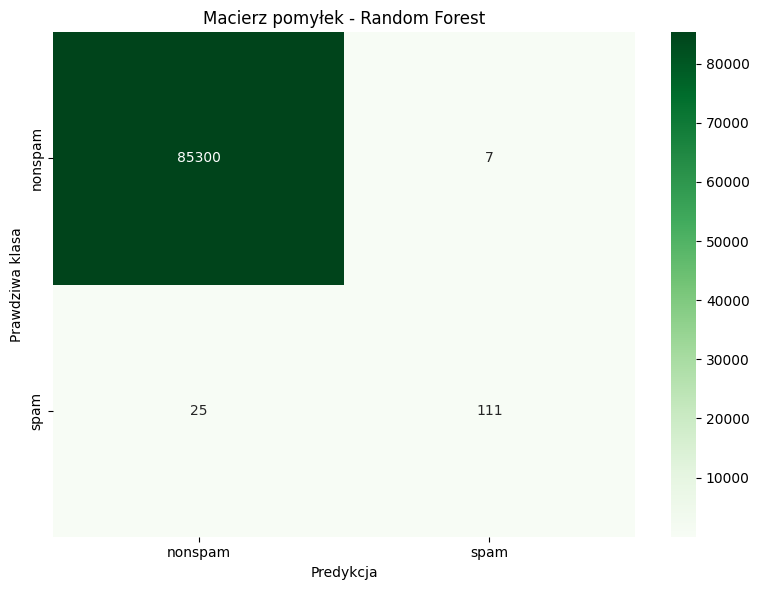


Raport klasyfikacji:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.94      0.82      0.87       136

    accuracy                           1.00     85443
   macro avg       0.97      0.91      0.94     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

print("\nMacierz pomyłek:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['nonfraud', 'fraud'],
            yticklabels=['nonfraud', 'fraud'])
plt.title('Macierz pomyłek - Random Forest')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Predykcja')
plt.tight_layout()
plt.show()

print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred_rf))

Macierz pomyłek dla lasu losowego ma problem z wykrywaniem fałszywych wartości. Jakość modelu jest natomiast dużo lepsza. Model wykrył 82% przypadków oszustw (recall = 0.82). Precyzja modelu wynosi 94% (precision=0.94). F1-score wynosi natomiast 87%.


### Naiwny klasyfikator Bayesowski

Kolejny model to **naiwny klasyfikator Bayesowski**. **Naiwny klasyfikator** Bayesowski to algorytm statystyczny oparty na twierdzeniu Bayesa, który przewiduje przynależność do danej klasy, zakładając upraszczające założenie o wzajemnej niezależności wszystkich cech wejściowych.

In [ ]:
model_nb = GaussianNB()
y_pred_nb = model_nb.fit(X_train, y_train).predict(X_test)
y_pred_nb


array([1, 0, 0, ..., 0, 0, 0])

=== Naive Bayes (Gaussian) ===
Accuracy: 0.9781

Macierz pomyłek:
[[83456  1851]
 [   21   115]]


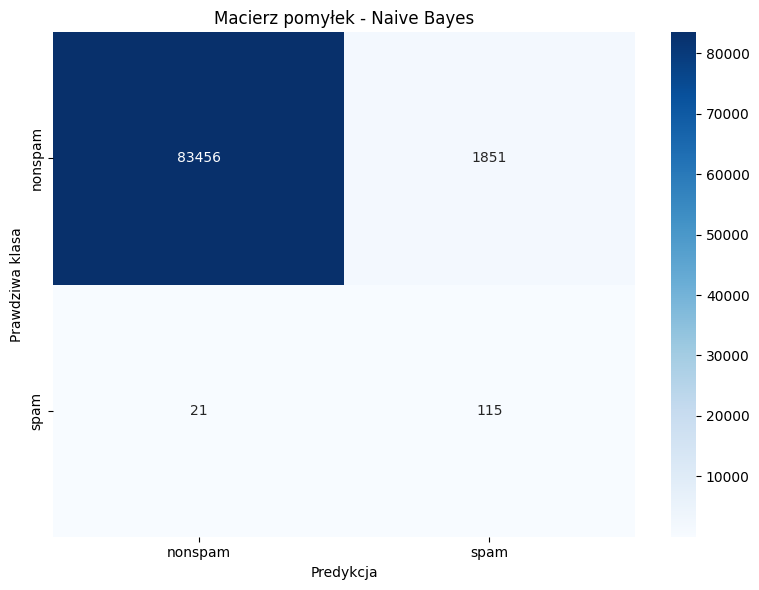


Raport klasyfikacji:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85307
           1       0.06      0.85      0.11       136

    accuracy                           0.98     85443
   macro avg       0.53      0.91      0.55     85443
weighted avg       1.00      0.98      0.99     85443



In [ ]:
print("=== Naive Bayes (Gaussian) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")

print("\nMacierz pomyłek:")
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(cm_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['nonfraud', 'fraud'],
            yticklabels=['nonfraud', 'fraud'])
plt.title('Macierz pomyłek - Naive Bayes')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Predykcja')
plt.tight_layout()
plt.show()

print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred_nb))

Ten model jest lepszy niż KNN i gorszy niż Random Forest. Model wykrył tylko 66% wszystkich oszustw. Precyzja modelu wynosi tylko 6%. F1-score wynosi zaledwie 11%, co oznacza, że lepiej go pominąć w analizie.

### Regresja logistyczna

Kolejnym modelem jest **regresja logistyczna**. **Regresja logistyczna** to model statystyczny, który przewiduje prawdopodobieństwo przynależności do jednej z dwóch klas poprzez dopasowanie danych do funkcji logistycznej, co pozwala na efektywną klasyfikację binarną.

In [13]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [14]:
y_pred_reg = model.predict(X_test)

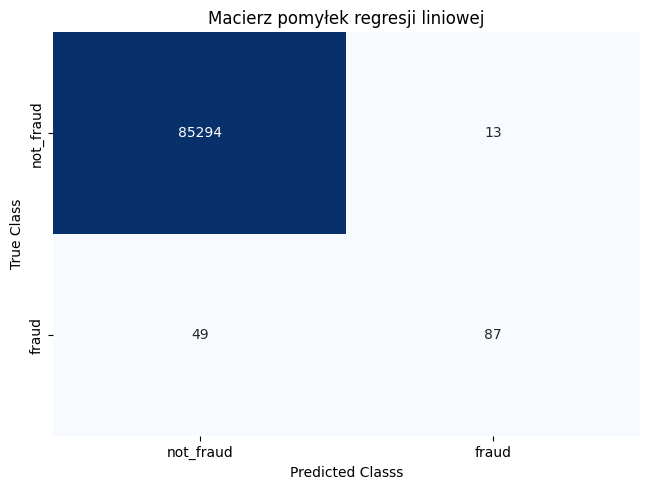


Raport regresji liniowej:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.87      0.64      0.74       136

    accuracy                           1.00     85443
   macro avg       0.93      0.82      0.87     85443
weighted avg       1.00      1.00      1.00     85443



In [15]:
class_names = ['not_fraud', 'fraud']
matrix = confusion_matrix(y_test, y_pred_reg)

matrix_frame = pd.DataFrame(matrix, index=class_names, columns=class_names)

sns.heatmap(matrix_frame, annot=True, cbar=None, cmap="Blues", fmt='g')
plt.title("Macierz pomyłek regresji liniowej")
plt.tight_layout()
plt.ylabel("True Class")
plt.xlabel("Predicted Classs")
plt.show()

print("\nRaport regresji liniowej:")
print(classification_report(y_test, y_pred_reg))

Model regresji logistycznej poprawnie rozpoznał 87% przypadków oszustw. Recall w tym wypadku wynosi 64%. F1-score jest też na dość wysokim poziomie, wynoszącym 74%.

### SVM

Ostatnim wykorzystanym modelem jest **SVM**. **SVM** to algorytm klasyfikacji, który wyszukuje w przestrzeni danych optymalną hiperpłaszczyznę rozdzielającą klasy z możliwie największym marginesem bezpieczeństwa między nimi.

In [16]:
model_svm = SVC(kernel='linear')
model_svm.fit(X_train, y_train)

SVC(kernel='linear')

In [17]:
y_pred_svm = model_svm.predict(X_test)

=== SVM ===
Accuracy: 0.9994

Macierz pomyłek:
[[85280    27]
 [   27   109]]


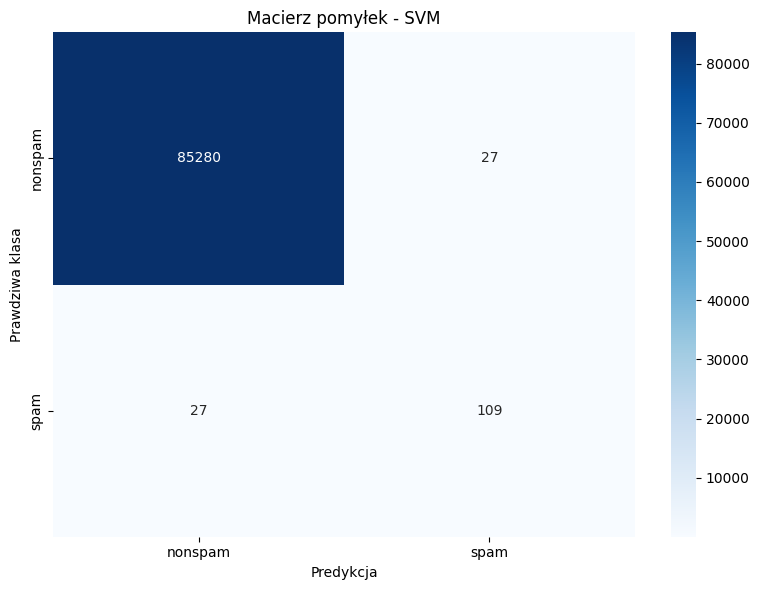


Raport SVM:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.80      0.80      0.80       136

    accuracy                           1.00     85443
   macro avg       0.90      0.90      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
print("=== SVM ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

print("\nMacierz pomyłek:")
cm_nb = confusion_matrix(y_test, y_pred_svm)
print(cm_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['nonfraud', 'fraud'],
            yticklabels=['nonfraud', 'fraud'])
plt.title('Macierz pomyłek - SVM')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Predykcja')
plt.tight_layout()
plt.show()

print("\nRaport SVM:")
print(classification_report(y_test, y_pred_svm))

Precyzja modelu SVM w rozpoznawaniu oszustw wynosi 80%, co oznacza, że większość transakcji oznaczonych jako podejrzane faktycznie nimi była. Co istotne, wskaźnik recall również wynosi 80%, co pokazuje, że model skutecznie identyfikuje zdecydowaną większość realnych oszustw. Wynik f1-score na poziomie 0.80 potwierdza wysoką stabilność i skuteczność modelu w balansowaniu między precyzją a czułością. Biorąc pod uwagę bardzo dużą dysproporcję w zbiorze danych (tylko 136 przypadków oszustw na ponad 85 tysięcy transakcji), wyniki te należy uznać za bardzo dobre.

### LIME

In [ ]:
feature_names = credit.columns.tolist()
class_names = ['Normal', 'Fraud']

In [ ]:
model_xgb = xgb.XGBClassifier(random_state=42)
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    verbose=True,
    random_state=42
)

In [ ]:
fraud_first = np.where(y_test==1)[0]
idx = fraud_first[0]

print(f"Wyjaśnienie transakcji o indeksie: {idx}")
exp = explainer.explain_instance(
    X_test[idx],
    model_xgb.predict_proba,
    num_features=10
)

exp.show_in_notebook(show_table=True)

Wyjaśnienie transakcji o indeksie: 0
Intercept -0.00806851571046345
Prediction_local [0.03150081]
Right: 0.99999976


Analiza lokalna modelu XGBoost wykazała, że badana transakcja posiada jednoznaczny profil nadużycia, w którym wszystkie kluczowe zmienne zgodnie wspierają werdykt o oszustwie. Najsilniejszą wagę diagnostyczną przypisano zmiennym ukrytym $V14$ ($-9.37$) oraz $V17$ ($-19.24$). Ich ekstremalnie niskie wartości stanowią statystyczną sygnaturę anomalii, odpowiadającą w praktyce krytycznym niezgodnościom behawioralnym lub geograficznym. Dodatkowy wpływ zmiennej $V11$ ($5.30$) potwierdza wystąpienie nietypowego wzorca operacji, a kwota 364.19 przekracza wyznaczony próg ryzyka, dopełniając obrazu nadużycia.

Mimo różnicy w precyzji matematycznej między głównym modelem a lokalnym przybliżeniem LIME (tzw. local fidelity error), oba algorytmy zachowują pełną spójność co do kierunku klasyfikacji. Brak jakichkolwiek czynników przemawiających za legalnością transakcji świadczy o wysokiej separacji tego przypadku od wzorców prawidłowych. Wnioski te pozwalają na jednoznaczną klasyfikację operacji jako próby oszustwa, wynikającą z nałożenia się anomalii kwotowej na krytyczne odchylenia parametrów sesji.

# Podsumowanie i Wnioski Końcowe

## 1. Porównanie skuteczności modeli
Głównym wyzwaniem w projekcie był silny brak zbalansowania klas (oszustwa stanowią jedynie 0,17% zbioru). W takim przypadku miara **Accuracy**  jest nieobiektywna, ponieważ model przewidujący zawsze klasę „brak oszustwa” osiągnąłby 99,8% skuteczności, nie wykrywając żadnego przestępstwa.

Poniższa tabela przedstawia zestawienie wyników dla kluczowej klasy **1 (Fraud)**:

| Model | Accuracy | Precision | Recall (Czułość) | F1-Score | Status |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **Random Forest** | **99,96%** | **0,94** | **0,82** | **0,87** | **Lider zestawienia** |
| **SVM (Linear)** | **99,93%** | **0,80** | **0,80** | **0,80** | **Wysoka stabilność** |
| **Regresja Logistyczna** | 99,92% | 0,87 | 0,64 | 0,74 | Dobra baza |
| **Naive Bayes** | 99,28% | 0,06 | 0,66 | 0,11 | Dużo błędnych alarmów |
| **k-Nearest Neighbors** | 99,93% | 0,55 | 0,04 | 0,08 | Model nieużyteczny |

---

## 2. Kluczowe obserwacje

### Najlepszy model: Random Forest
Model ten najlepiej poradził sobie z identyfikacją wzorców oszustw. Wynik **F1-Score na poziomie 0,87** oznacza, że system jest w stanie wykryć zdecydowaną większość prób nadużyć, zachowując przy tym bardzo wysoką precyzję.

### Wysoka skuteczność modelu SVM
W nowej konfiguracji model **SVM z Linear Kernel** wykazał znaczącą poprawę skuteczności:
* **Balans metryk:** Uzyskanie wyników **Precision (0.80)** oraz **Recall (0.80)** na tym samym poziomie świadczy o doskonałym zbalansowaniu modelu. Model nie faworyzuje żadnej z metryk, co czyni go bardzo przewidywalnym narzędziem.
* **Odporność na szum:** Mimo ogromnej przewagi klasy negatywnej (ponad 85 000 rekordów), SVM precyzyjnie wyznaczył hiperpłaszczyznę oddzielającą oszustwa, co sugeruje, że cechy po transformacji PCA są w dużym stopniu liniowo separowalne.



### Problemy pozostałych modeli
* **k-NN:** Algorytm niemal całkowicie zawiódł w wykrywaniu klasy mniejszościowej (Recall 0.04). Wynika to z faktu, że w przestrzeni wielowymiarowej pojedyncze punkty reprezentujące oszustwa są "przykryte" przez gęsto rozmieszczone legalne transakcje.
* **Naive Bayes:** Choć wykrywa 66% oszustw, generuje zbyt wiele błędnych alarmów (Precision 6%), co w praktyce bankowej paraliżowałoby pracę działu weryfikacji.

---

## 3. Interpretacja wyników (LIME & XGBoost)
Analiza lokalna przy pomocy biblioteki **LIME** pozwoliła „otworzyć czarną skrzynkę” modelu XGBoost.
* Kluczowymi cechami determinującymi oszustwo okazały się zmienne **V14, V17 oraz V11**.
* Wartości ekstremalne tych składowych są statystyczną sygnaturą anomalii.
* Dzięki LIME wiemy, że model podejmuje decyzje w oparciu o konkretne odchylenia behawioralne, a nie dziełem przypadku.

